# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import yfinance as yf
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme("talk")
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (8, 6)
SEED = 1234

# Market data

In [2]:
# list of tickers
TICKERS = (
    "AAPL",
    "MSFT",
    "NVDA",
    "AMZN",
    "GOOGL",
    "META",
    "ORCL",
    "CRM",
    "ADBE",
    "AMD",
    "JPM",
    "BAC",
    "WFC",
    "GS",
    "MS",
    "C",
    "BLK",
    "AXP",
    "SCHW",
    "USB",
    "JNJ",
    "PFE",
    "MRK",
    "ABBV",
    "LLY",
    "UNH",
    "TMO",
    "DHR",
    "BMY",
    "AMGN",
    "XOM",
    "CVX",
    "COP",
    "SLB",
    "EOG",
    "CAT",
    "DE",
    "UNP",
    "GE",
    "HON",
    "WMT",
    "COST",
    "HD",
    "MCD",
    "SBUX",
    "NKE",
    "DIS",
    "NFLX",
    "KO",
    "PEP",
    "T",
    "VZ",
    "CMCSA",
    "INTC",
    "QCOM",
    "IBM",
    "BA",
    "RTX",
    "NEE",
    "DUK",
)

In [3]:
# load tickers info from file or fetch from yfinance if not available
try:
    df_tickers = pd.read_csv("data/tickers.csv").set_index("ticker")
except FileNotFoundError:
    print("tickers.csv not found, fetching data from yfinance...")
    rows = []
    for t in TICKERS:
        info = yf.Ticker(t).info
        rows.append(
            {"ticker": t, "name": info.get("shortName"), "sector": info.get("sector")}
        )

    _df_tickers = pd.DataFrame(rows).sort_values("sector")
    df_tickers = _df_tickers.sort_values("ticker").set_index("ticker")
    # save for future use
    _df_tickers.sort_values("ticker").reset_index(drop=True).to_csv(
        "data/tickers.csv", index=False
    )
except Exception as e:
    print(f"Error loading tickers.csv: {e}")
    raise

In [4]:
df_tickers.head()

,name,sector
ticker,,
AAPL,Apple Inc.,Technology
ABBV,AbbVie Inc.,Healthcare
ADBE,Adobe Inc.,Technology
AMD,"Advanced Micro Devices, Inc.",Technology
AMGN,Amgen Inc.,Healthcare


In [5]:
# download historical price data for the tickers
start = "2021-01-01"
end = "2026-01-01"

try:
    df_prices = pd.read_csv("data/prices.csv", index_col="Date")
except FileNotFoundError:
    print("prices.csv not found, fetching data from yfinance...")
    prices = yf.download(
        TICKERS, start=start, end=end, auto_adjust=True, progress=False
    )["Close"]
    # save for future use
    prices.reset_index().to_csv("data/prices.csv", index=False)
except Exception as e:
    print(f"Error loading prices.csv: {e}")
    raise

In [6]:
df_prices.head()

,AAPL,ABBV,ADBE,AMD,AMGN,AMZN,AXP,BA,BAC,BLK,...,SLB,T,TMO,UNH,UNP,USB,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,125.856712,86.047379,485.339996,92.300003,192.309921,159.331497,110.722672,202.720001,26.464052,626.998108,...,19.601675,15.702639,465.205017,319.662140,180.571716,36.844452,42.871235,26.340195,45.541061,33.693794
2021-01-05,127.412788,86.937164,485.690002,92.769997,193.243210,160.925507,111.313599,211.630005,26.666731,630.314636,...,20.655432,15.606633,471.022278,315.363403,182.786514,36.964291,42.674553,27.076303,45.298634,35.317581
2021-01-06,123.123863,86.186165,466.309998,90.330002,197.901245,156.919006,115.431458,211.029999,28.332306,648.291565,...,21.798492,15.910659,478.407227,328.598022,186.611237,39.153229,43.191772,28.991949,45.581463,36.218796
2021-01-07,127.325226,87.108589,477.739990,95.160004,198.554535,158.108002,114.518410,212.710007,28.957994,661.928406,...,22.218208,15.953326,493.315216,333.866364,189.208481,39.936138,43.094582,29.648237,45.578342,36.502949
2021-01-08,128.424194,87.565727,485.100006,94.580002,202.347122,159.134995,114.631378,209.899994,28.667175,667.247192,...,22.182491,15.843309,505.117493,332.366272,194.634262,39.400887,42.557095,29.435385,45.572132,36.908909


In [7]:
# clean data and compute returns

# Drop names with missing data
df_prices = df_prices.dropna()

# Daily log returns
df_returns = np.log(df_prices / df_prices.shift(1)).dropna()

print(df_returns.shape)
df_returns.head()

(1254, 60)


,AAPL,ABBV,ADBE,AMD,AMGN,AMZN,AXP,BA,BAC,BLK,...,SLB,T,TMO,UNH,UNP,USB,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-05,0.012288,0.010288,0.000721,0.005079,0.004841,0.009955,0.005323,0.043014,0.007629,0.005276,...,0.052363,-0.006133,0.012427,-0.013539,0.012191,0.003247,-0.004598,0.027563,-0.005337,0.047067
2021-01-06,-0.034241,-0.008676,-0.040720,-0.026654,0.023819,-0.025212,0.036325,-0.002839,0.060586,0.028121,...,0.053862,0.019293,0.015557,0.041110,0.020709,0.057531,0.012047,0.068359,0.006224,0.025197
2021-01-07,0.033554,0.010646,0.024216,0.052090,0.003296,0.007549,-0.007941,0.007929,0.021844,0.020817,...,0.019071,0.002678,0.030686,0.015906,0.013822,0.019799,-0.002253,0.022384,-0.000068,0.007815
2021-01-08,0.008594,0.005234,0.015288,-0.006114,0.018921,0.006475,0.000986,-0.013299,-0.010094,0.008003,...,-0.001609,-0.006920,0.023643,-0.004503,0.028273,-0.013493,-0.012551,-0.007205,-0.000136,0.011060
2021-01-11,-0.023523,0.016182,-0.022642,0.027839,-0.003865,-0.021754,-0.005930,-0.014927,0.016464,0.013433,...,0.006020,-0.005182,0.002048,-0.007291,-0.006741,0.000405,-0.005900,0.001506,0.004491,0.029905


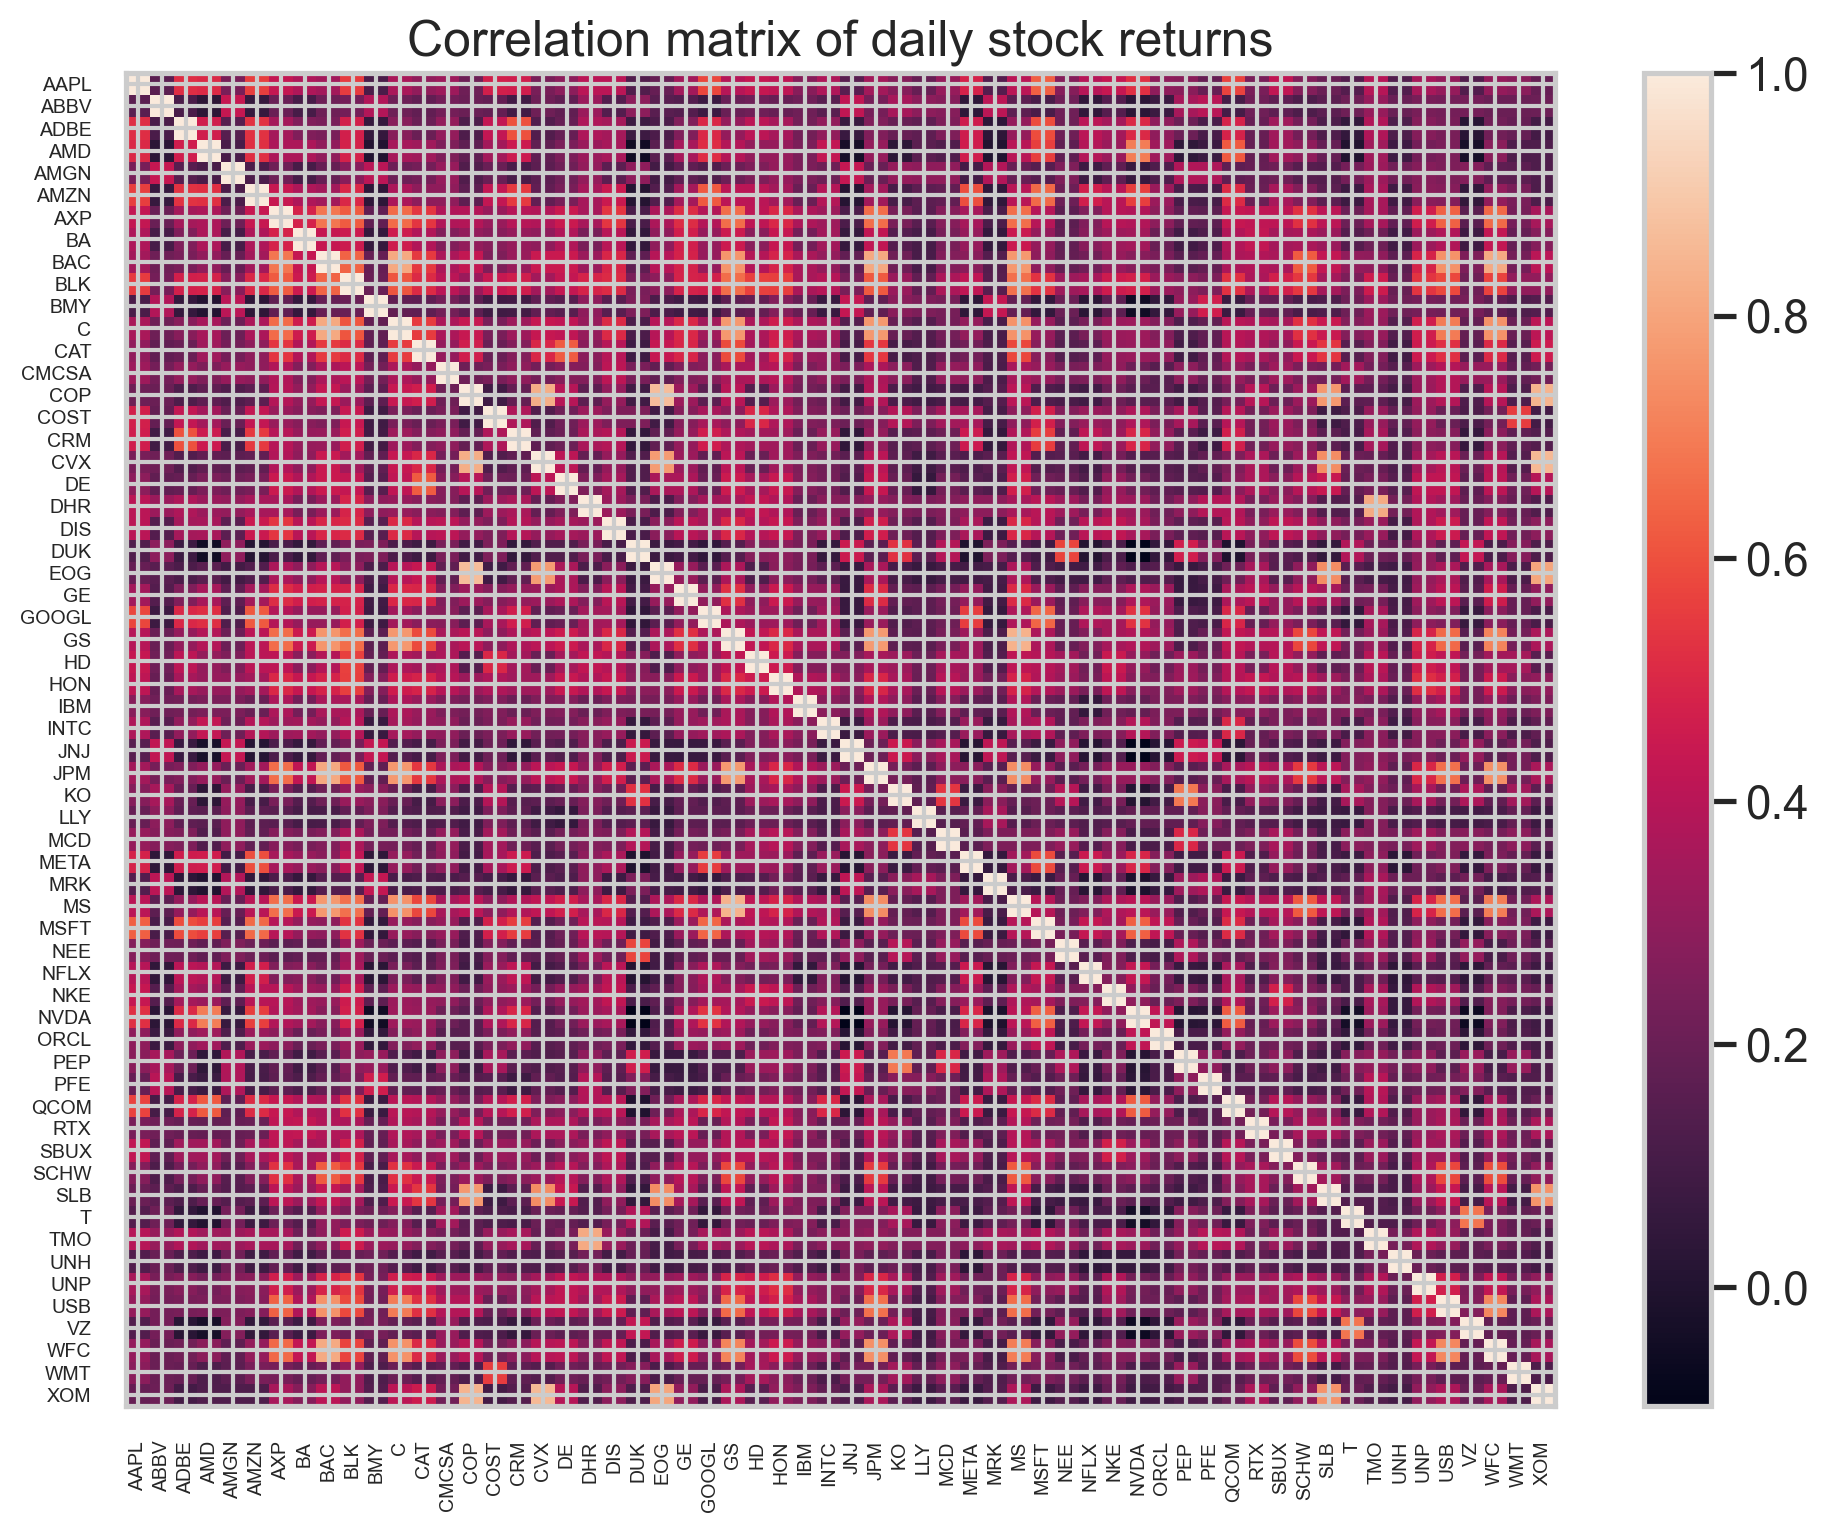

In [8]:
# quick look at correlation matrix of returns
corr = df_returns.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.title("Correlation matrix of daily stock returns")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr.index)), corr.index, fontsize=7)
plt.tight_layout()
plt.show()

In [9]:
# PCA on returns

# A useful choice here is to standardize each stock first, so PCA is driven by the
# correlation structure rather than raw volatility differences.

scaler = StandardScaler(with_mean=True, with_std=True)
X = scaler.fit_transform(df_returns)  # shape: (T, N)

pca = PCA(n_components=10)
pca.fit(X)

explained = pca.explained_variance_ratio_
loadings = pca.components_.T  # shape: (N, 10)

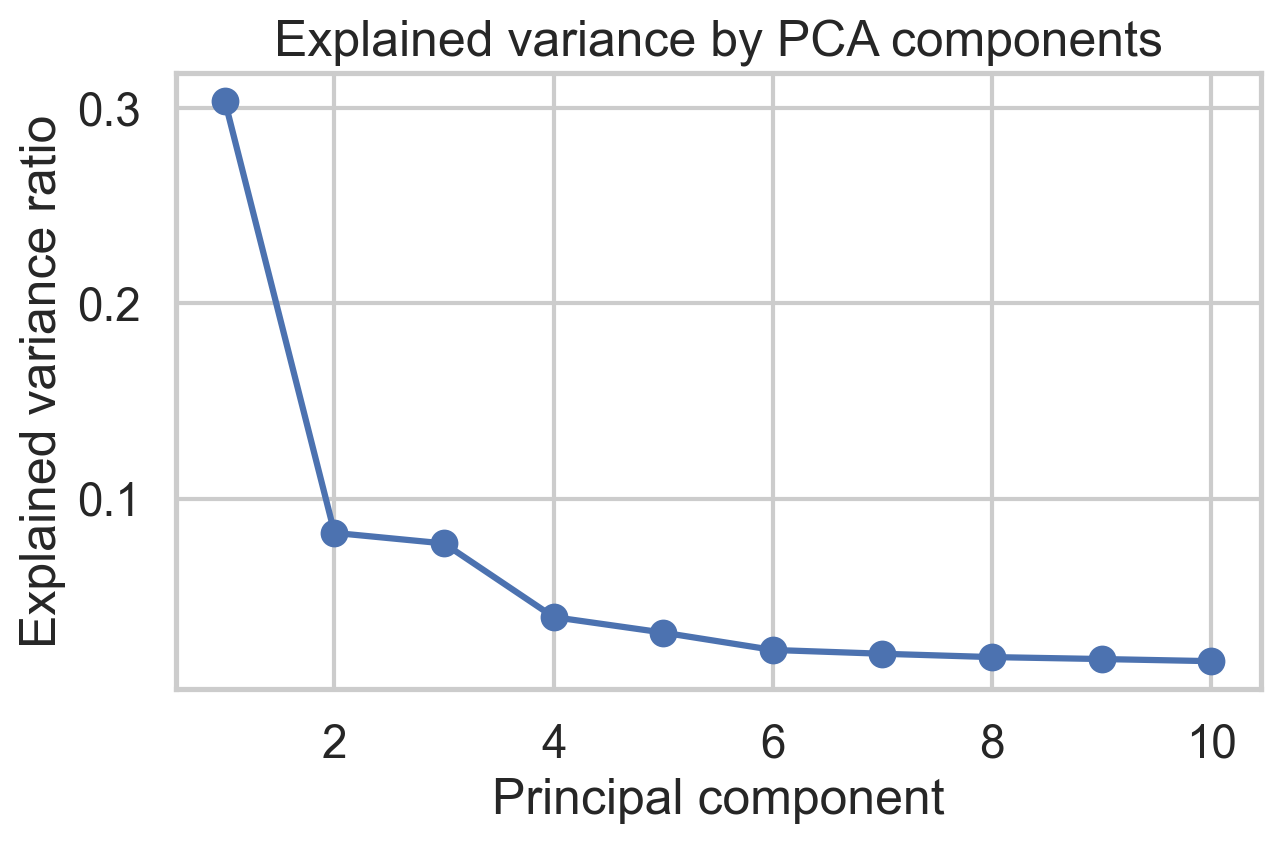

In [10]:
# explained variance plot

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(explained) + 1), explained, marker="o")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Explained variance by PCA components")
plt.grid(True)
plt.show()

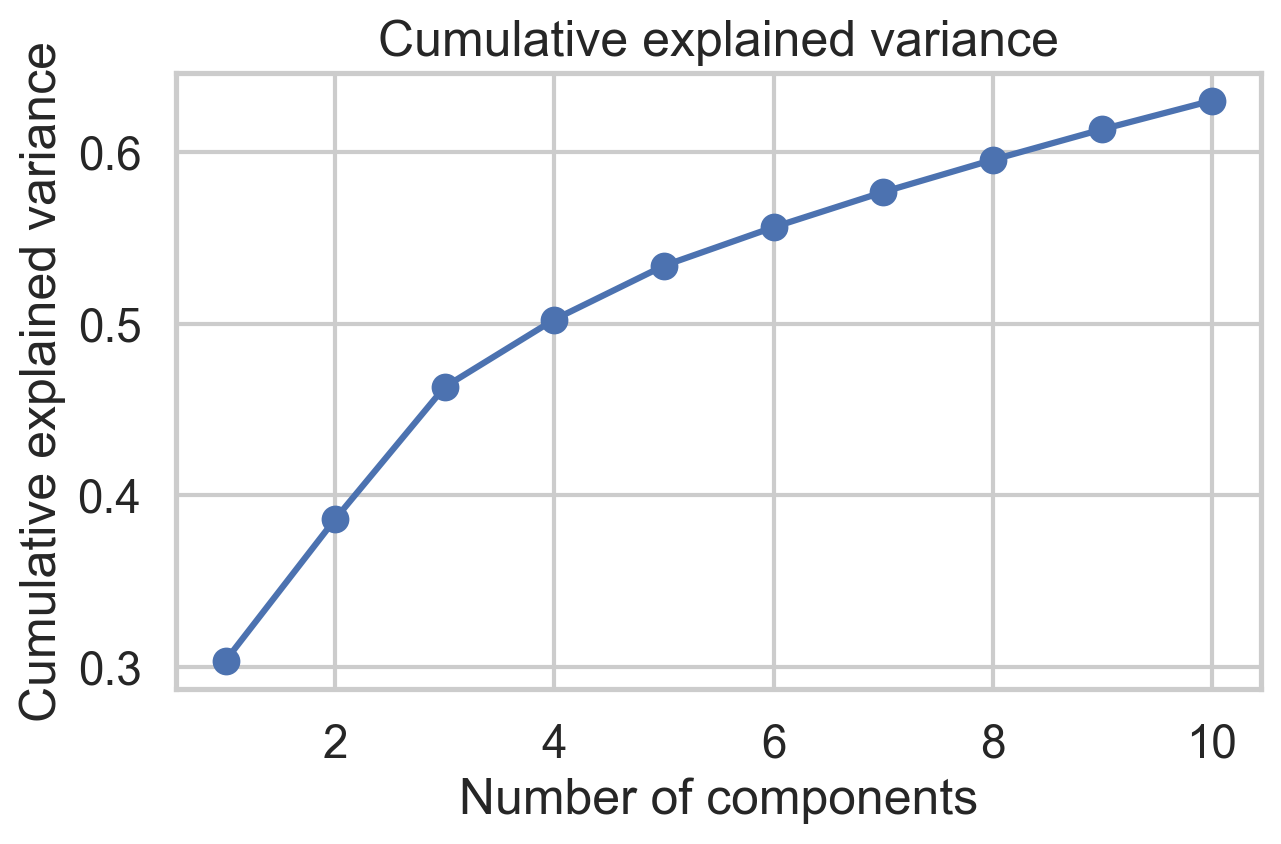

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(explained) + 1), np.cumsum(explained), marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative explained variance")
plt.grid(True)
plt.show()

In [12]:
# inspect the first factor
# for equities, PC1 is often close to a "market factor" with positive loadings across
# most stocks, while PC2 and PC3 may show sector or style patterns.

pc1 = pd.Series(loadings[:, 0], index=df_returns.columns).sort_values()
pc2 = pd.Series(loadings[:, 1], index=df_returns.columns).sort_values()
pc3 = pd.Series(loadings[:, 2], index=df_returns.columns).sort_values()

print("PC1 loadings:")
print(pc1)

print("\nPC2 loadings:")
print(pc2)

print("\nPC3 loadings:")
print(pc3)

PC1 loadings:
UNH      0.063140
MRK      0.065508
LLY      0.069475
DUK      0.071818
BMY      0.073880
VZ       0.074996
JNJ      0.075222
PFE      0.081423
T        0.081550
ABBV     0.083242
PEP      0.089525
WMT      0.090014
AMGN     0.091409
NEE      0.092394
ORCL     0.096804
NFLX     0.097604
KO       0.098833
MCD      0.108539
EOG      0.112270
IBM      0.115432
XOM      0.115472
INTC     0.117835
META     0.119132
SLB      0.121899
COST     0.122589
COP      0.122709
RTX      0.123430
CMCSA    0.125685
NVDA     0.125966
ADBE     0.126338
CVX      0.127718
NKE      0.129140
AMD      0.129177
TMO      0.130407
CRM      0.131049
SBUX     0.132009
GOOGL    0.132361
DHR      0.133167
DE       0.133659
BA       0.135434
AMZN     0.140430
MSFT     0.141325
SCHW     0.142314
GE       0.143547
HD       0.144234
QCOM     0.146745
UNP      0.149681
DIS      0.150947
AAPL     0.152156
CAT      0.153296
WFC      0.162872
HON      0.163960
USB      0.164719
JPM      0.174834
C        0.176

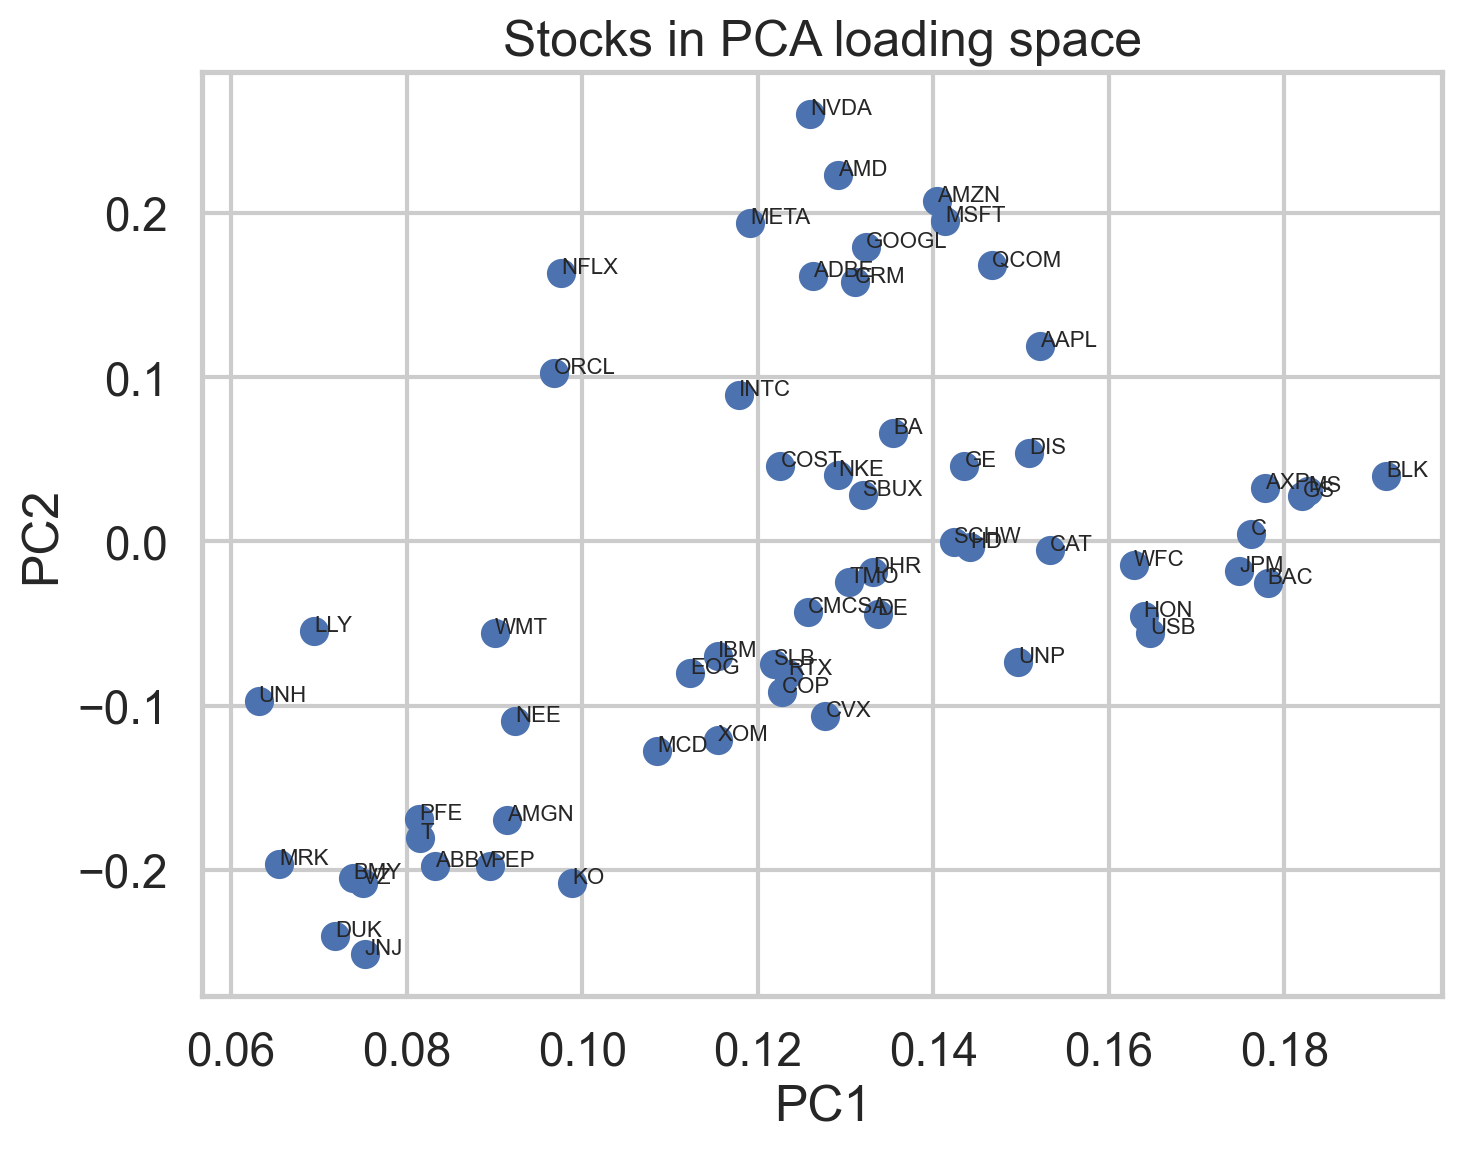

In [13]:
# scatter plot in PCA space

plt.figure(figsize=(8, 6))
plt.scatter(loadings[:, 0], loadings[:, 1])

for i, ticker in enumerate(df_returns.columns):
    plt.text(loadings[i, 0], loadings[i, 1], ticker, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Stocks in PCA loading space")
plt.grid(True)
plt.show()

In [14]:
# often:
# PC1: broad market exposure
# PC2 / PC3: sector or style splits
# higher PCs: more idiosyncratic structure

In [15]:
# recover pca.components_ from SVD
# X is already centered and standardized
U, S, Vt = np.linalg.svd(X, full_matrices=False)

components_from_svd = Vt
loadings_from_svd = Vt.T

# signs of components can differ, but the absolute values should match
print(np.allclose(np.abs(pca.components_), np.abs(components_from_svd[:10])))

explained_variance = (S**2) / (X.shape[0] - 1)
explained_variance_ratio = explained_variance / explained_variance.sum()

print(explained_variance_ratio[:10])
print(pca.explained_variance_ratio_)

True
[0.30369848 0.08243728 0.07701907 0.03928461 0.03132283 0.0224335
 0.02048886 0.01877485 0.01778062 0.01668716]
[0.30369848 0.08243728 0.07701907 0.03928461 0.03132283 0.0224335
 0.02048886 0.01877485 0.01778062 0.01668716]


In [16]:
n_clusters = 6
Z = loadings[:, :3]  # use first 3 PCs as features for clustering

kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=20)
labels = kmeans.fit_predict(Z)

clusters = pd.DataFrame(
    {
        "ticker": df_returns.columns,
        "cluster": labels,
        "pc1": loadings[:, 0],
        "pc2": loadings[:, 1],
        "pc3": loadings[:, 2],
    }
).sort_values(["cluster", "ticker"])

clusters.head()

,ticker,cluster,pc1,pc2,pc3
1,ABBV,0,0.083242,-0.197859,-0.093652
4,AMGN,0,0.091409,-0.169571,-0.128381
10,BMY,0,0.073880,-0.204729,-0.091859
21,DUK,0,0.071818,-0.240240,-0.148577
30,JNJ,0,0.075222,-0.251328,-0.148412


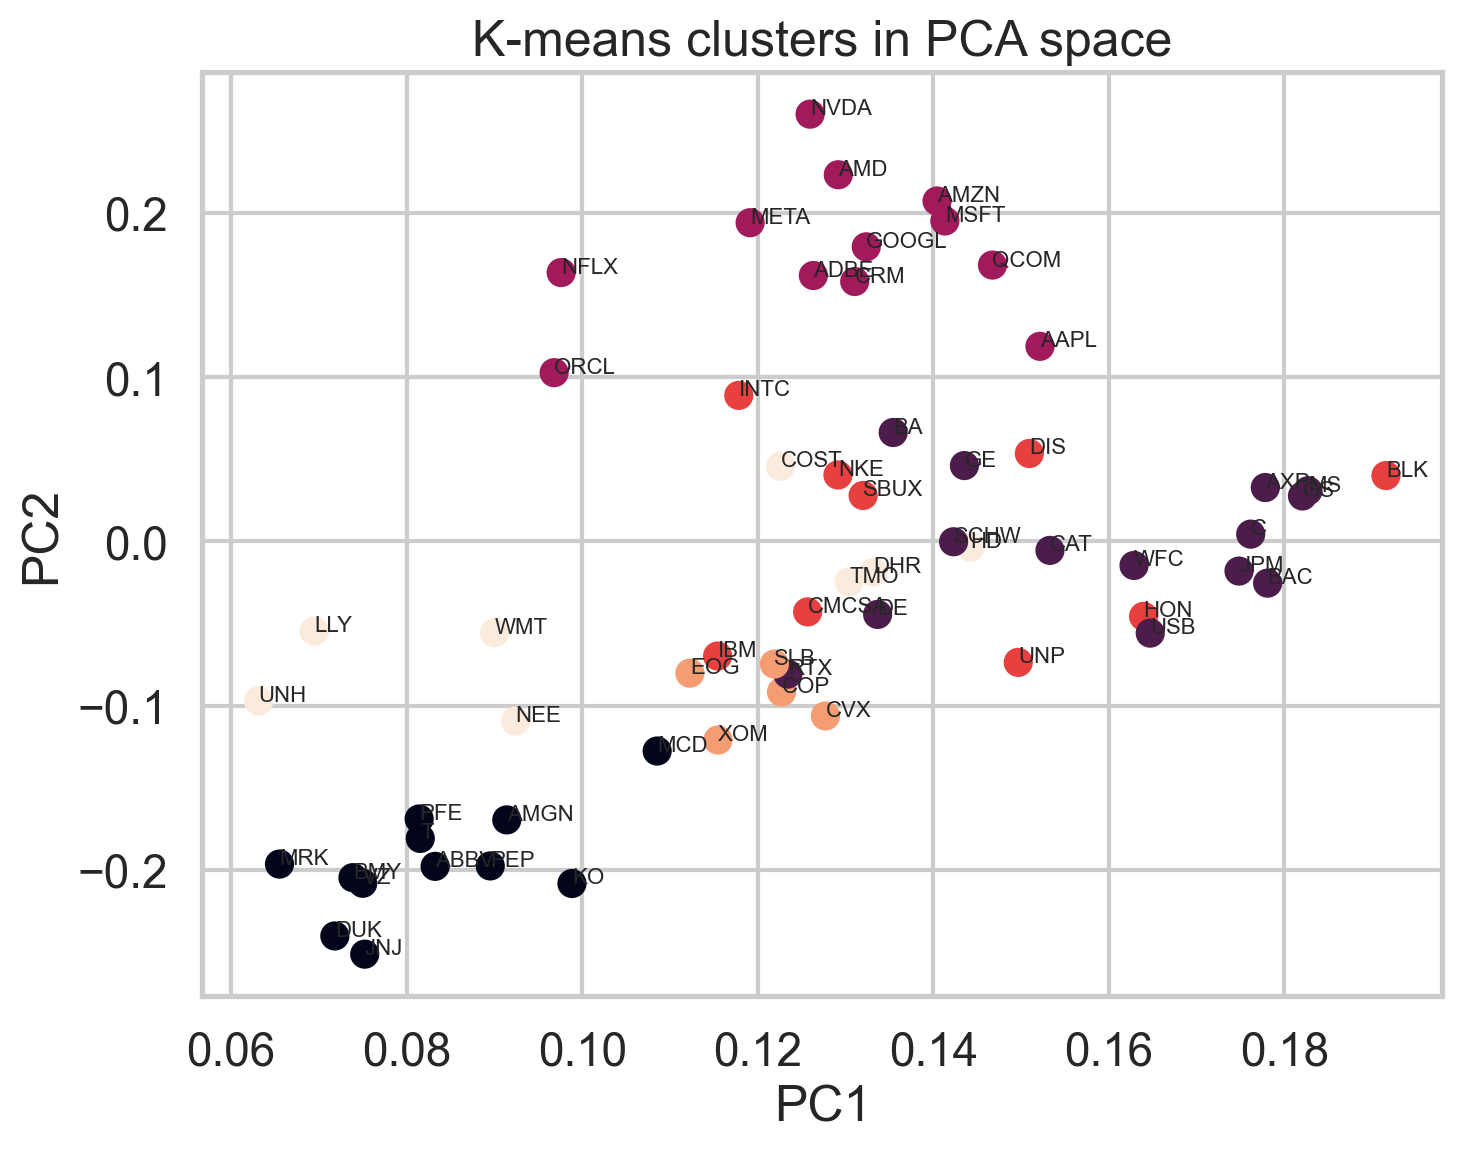

In [17]:
# plot clusters in PCA space
plt.figure(figsize=(8, 6))
scatter = plt.scatter(loadings[:, 0], loadings[:, 1], c=labels)

for i, ticker in enumerate(df_returns.columns):
    plt.text(loadings[i, 0], loadings[i, 1], ticker, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means clusters in PCA space")
plt.grid(True)
plt.show()

In [18]:
# print stocks by cluster
for k in range(n_clusters):
    names = clusters.loc[clusters["cluster"] == k, "ticker"].tolist()
    print(f"Cluster {k}: {names}")

Cluster 0: ['ABBV', 'AMGN', 'BMY', 'DUK', 'JNJ', 'KO', 'MCD', 'MRK', 'PEP', 'PFE', 'T', 'VZ']
Cluster 1: ['AXP', 'BA', 'BAC', 'C', 'CAT', 'DE', 'GE', 'GS', 'JPM', 'MS', 'RTX', 'SCHW', 'USB', 'WFC']
Cluster 2: ['AAPL', 'ADBE', 'AMD', 'AMZN', 'CRM', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA', 'ORCL', 'QCOM']
Cluster 3: ['BLK', 'CMCSA', 'DIS', 'HON', 'IBM', 'INTC', 'NKE', 'SBUX', 'UNP']
Cluster 4: ['COP', 'CVX', 'EOG', 'SLB', 'XOM']
Cluster 5: ['COST', 'DHR', 'HD', 'LLY', 'NEE', 'TMO', 'UNH', 'WMT']


In [19]:
df_clusters_new = clusters.sort_values("ticker").set_index("ticker")

In [20]:
df_all = pd.concat([df_tickers, df_clusters_new], axis=1).sort_values("cluster")
df_all.head()

,name,sector,cluster,pc1,pc2,pc3
ticker,,,,,,
JNJ,Johnson & Johnson,Healthcare,0,0.075222,-0.251328,-0.148412
PEP,"Pepsico, Inc.",Consumer Defensive,0,0.089525,-0.197603,-0.205734
VZ,Verizon Communications Inc.,Communication Services,0,0.074996,-0.208153,-0.064046
DUK,Duke Energy Corporation (Holdin,Utilities,0,0.071818,-0.240240,-0.148577
BMY,Bristol-Myers Squibb Company,Healthcare,0,0.073880,-0.204729,-0.091859


In [21]:
# often clusters will correspond to intuitive groupings of stocks, e.g.:
# tech / semis
# banks / financials
# healthcare
# energy
# defensive consumer / utilities

# But K-means is only a similarity grouping, not a structural factor model.

In [22]:
# cluster on correlations directly
corr_features = df_returns.corr().values
kmeans_corr = KMeans(n_clusters=6, random_state=0, n_init=20)
labels_corr = kmeans_corr.fit_predict(corr_features)

clusters_corr = pd.DataFrame(
    {"ticker": df_returns.columns, "cluster": labels_corr}
).sort_values(["cluster", "ticker"])

clusters_corr.head()

,ticker,cluster
21,DUK,0
32,KO,0
34,MCD,0
39,NEE,0
44,PEP,0


In [23]:
print(
    "Takeaway:\n"
    "- PCA extracts a few dominant co-movement directions.\n"
    "- In stock returns, PC1 is often market-like.\n"
    "- PC2 and PC3 often reflect sector/style structure.\n"
    "- K-means groups stocks into similar buckets, but does not produce factor "
    "exposures."
)

Takeaway:
- PCA extracts a few dominant co-movement directions.
- In stock returns, PC1 is often market-like.
- PC2 and PC3 often reflect sector/style structure.
- K-means groups stocks into similar buckets, but does not produce factor exposures.
